# Genome-Level Heatmap

This tutorial demonstrates how to visualize genome-scale data using
ComplexHeatmap, faithfully porting R's genome-level heatmap tutorial
(13-genome-level-heatmap-v2.R).

Key techniques:
- Splitting heatmap rows by chromosome using `row_split`
- Adding column annotations based on sample subgroup
- Combining numeric + character heatmaps + row annotations via `+`
- `anno_mark` for gene labels with connector lines
- `anno_points` and `anno_barplot` for additional tracks

In [1]:
import numpy as np
import pandas as pd
import complexheatmap as ch
from complexheatmap import *
import grid_py as gp

## Load pre-processed genomic data

The bundled dataset (matching R's `genome_level_all.rds`) contains:
- `num_mat`: 2875 x 10 numeric matrix (1MB windows x 10 samples)
- `char_mat`: 2875 x 10 character matrix (CNV gain/loss)
- `chr` / `chr_level`: chromosome labels and ordering
- `subgroup`: sample subgroup labels (A/B)
- `at` / `labels`: gene marker positions and names
- `v`: 2875 x 2 numeric matrix for annotation tracks

In [2]:
gdata = load_genome_level_data()
num_mat = gdata["num_mat"]
char_mat = gdata["char_mat"]
chr_vec = gdata["chr"]
chr_level = gdata["chr_level"]
subgroup = gdata["subgroup"]
at = gdata["at"]
labels_g = gdata["labels"]
v = np.array(gdata["v"])

# Create ordered categorical for chromosome (like R's factor)
chr_factor = pd.Categorical(chr_vec, categories=chr_level, ordered=True)
subgroup_arr = np.array(subgroup)

print(f"num_mat: {num_mat.shape}")
print(f"char_mat: {char_mat.shape}")
print(f"Chromosomes: {len(chr_level)}")
print(f"Gene markers: {len(at)}")
print(f"v shape: {v.shape}")

num_mat: (2875, 10)
char_mat: (2875, 10)
Chromosomes: 22
Gene markers: 42
v shape: (2875, 2)


## Full vertical genome heatmap with multiple tracks

This matches R tutorial lines 43-58: a combination of two heatmaps and
three row annotations using the `+` operator.

- Numeric heatmap: green-white-red, split by chromosome and subgroup
- Character heatmap: CNV gain (red) / loss (blue)
- `anno_mark`: gene labels with connector lines
- `anno_points`: two-column scatter plot
- `anno_barplot`: barplot with conditional coloring

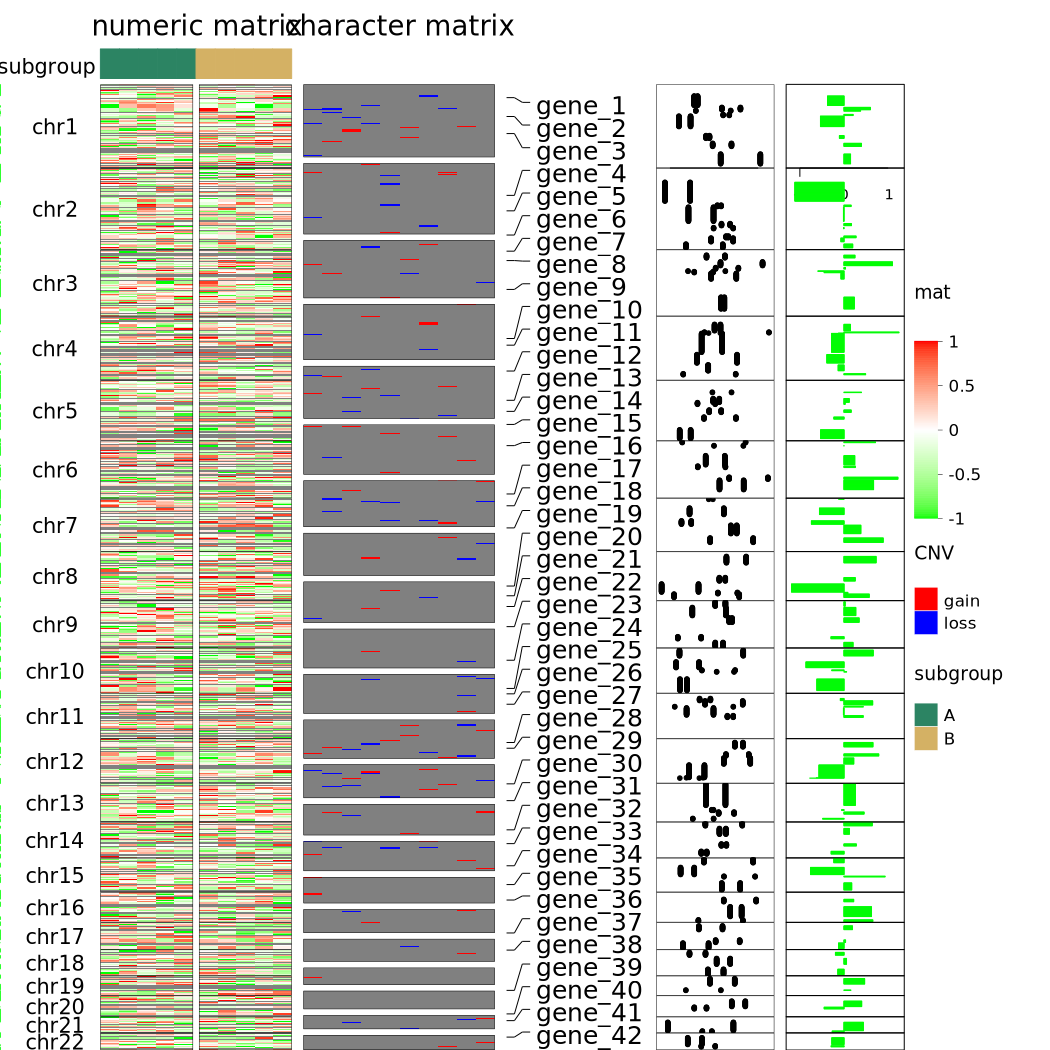

HeatmapList(['mat', 'CNV', 'heatmap_annotation_0', 'heatmap_annotation_1', 'heatmap_annotation_2'], direction='horizontal')

In [3]:
col_fun = color_ramp2([-1, 0, 1], ["green", "white", "red"])

# R: ht_opt$TITLE_PADDING = unit(c(4, 4), "points")
ha_top = HeatmapAnnotation(
    subgroup=subgroup_arr,
    annotation_name_side="left",
)

ht_list = Heatmap(num_mat, name="mat", col=col_fun,
    row_split=chr_factor, cluster_rows=False,
    show_column_dend=False,
    column_split=subgroup_arr, cluster_column_slices=False,
    column_title="numeric matrix",
    top_annotation=ha_top,
    row_title_rot=0, row_title_gp=gp.Gpar(fontsize=10),
    border=True,
    row_gap=gp.Unit(0, "points"),
    show_row_names=False,
    show_column_names=False,
) + \
Heatmap(char_mat, name="CNV",
    col={"gain": "red", "loss": "blue"},
    border=True, show_row_names=False, row_title_rot=0, row_title_gp=gp.Gpar(fontsize=10),
    column_title="character matrix",
    show_column_names=False,
) + \
rowAnnotation(label=anno_mark(at=at, labels=labels_g, which="row")) + \
rowAnnotation(pt=anno_points(v, which="row", size=0.5),
    annotation_name_rot=0,
    width=gp.Unit(2, "cm")) + \
rowAnnotation(bar=anno_barplot(v[:, 0], which="row",
    gp={"col": list(np.where(v[:, 0] > 0, "red", "green"))}),
    width=gp.Unit(2, "cm"), annotation_name_rot=0)

ht_list.draw(merge_legends=True)

## Inspecting the layout

Verify that the combined heatmap has the expected number of
tracks and chromosome slices.

In [4]:
ht_verify = Heatmap(
    num_mat, name="v1",
    row_split=chr_factor, cluster_rows=False, cluster_columns=False,
    show_row_names=False, row_title_rot=0, row_title_gp=gp.Gpar(fontsize=8),
) + Heatmap(
    char_mat, name="v2",
    col={"gain": "red", "loss": "blue"},
    show_row_names=False, row_title_gp=gp.Gpar(fontsize=8), row_title_rot=0
)
ht_verify.make_layout()
co = ht_verify.get_column_order()
print(f"Number of heatmaps in combined layout: {len(co)}")
n_slices = len(ht_verify.ht_list[0].row_order_list())
print(f"Row slices (chromosomes): {n_slices}")

Number of heatmaps in combined layout: 2
Row slices (chromosomes): 22


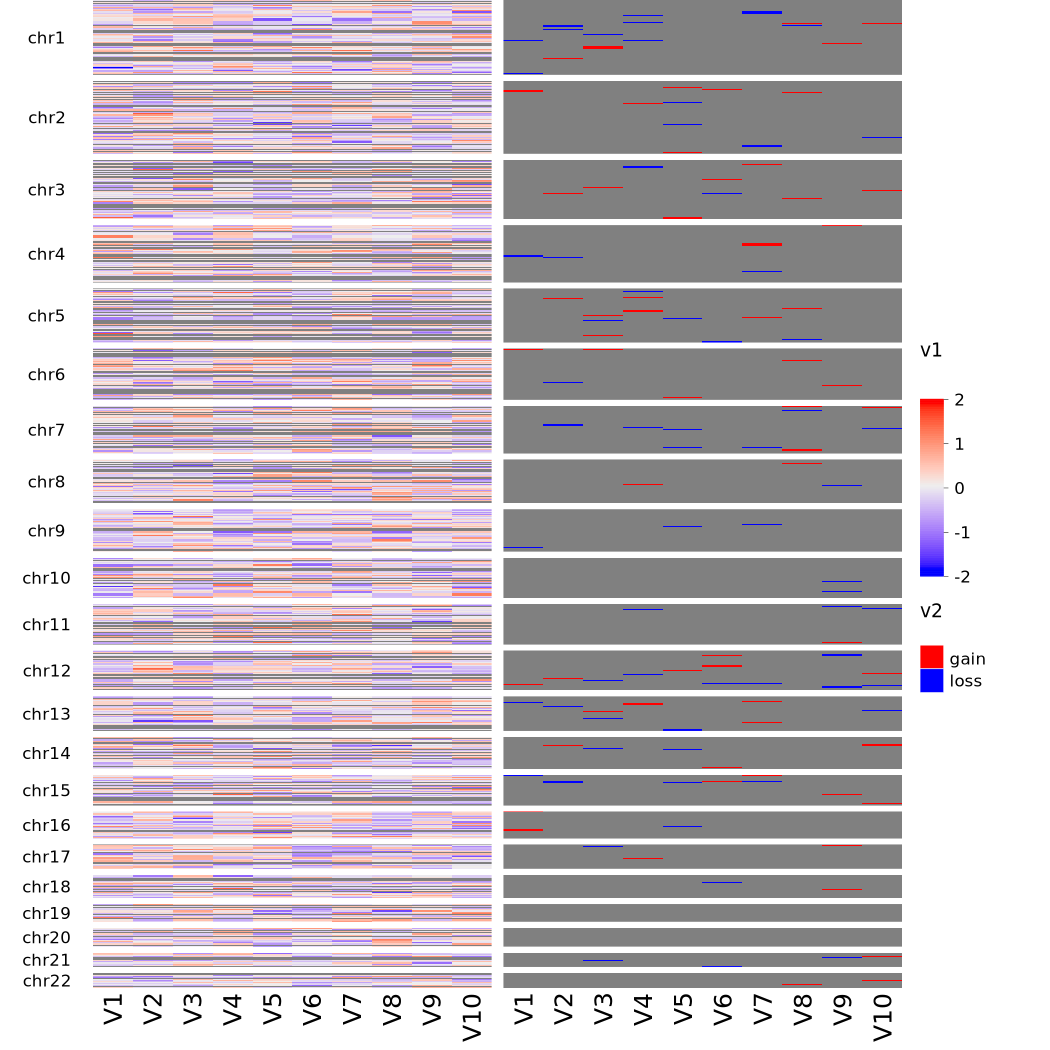

HeatmapList(['v1', 'v2'], direction='horizontal')

In [5]:
ht_verify.draw()

## Basic chromosome-split heatmap

A simpler example showing just the numeric matrix with chromosome
splitting and a top annotation.

/scratch/groups/xiaojie/nianping_scratch/Test_complexHeatmap/complexheatmap_py/complexheatmap/heatmap.py:835: RuntimeWarning: Mean of empty slice
  np.nanmean(self.matrix[:, ind], axis=1) for ind in order_list


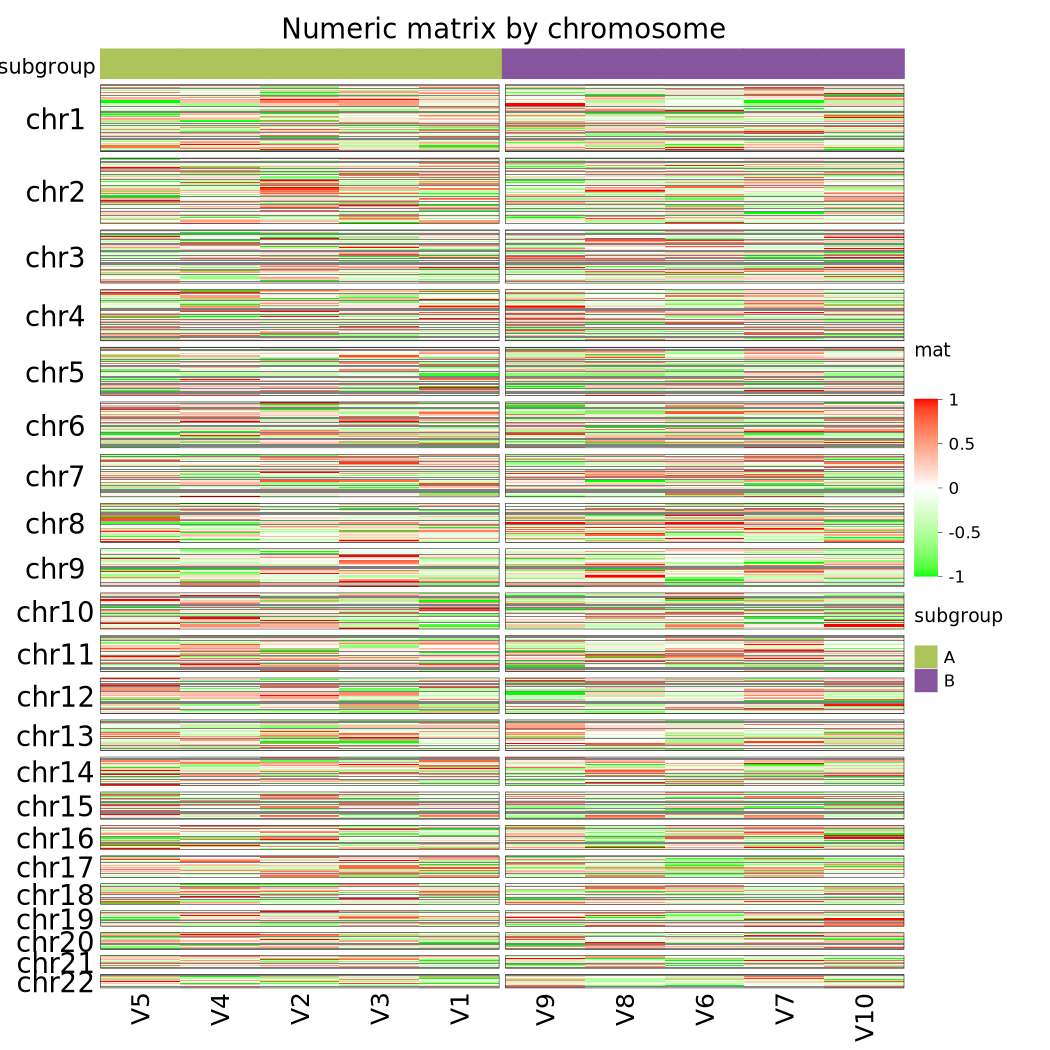

In [6]:
ht_simple = Heatmap(
    num_mat,
    name="mat",
    col=col_fun,
    row_split=chr_factor,
    cluster_rows=False,
    row_title_rot=0,
    show_column_dend=False,
    column_split=subgroup_arr,
    top_annotation=HeatmapAnnotation(subgroup=subgroup_arr, annotation_name_side="left"),
    show_row_names=False,
    border=True,
    column_title="Numeric matrix by chromosome",
)
ht_simple.draw()

## Horizontal genome heatmap (transposed, `%v%`)

R tutorial lines 67-86: the same data arranged horizontally using
`%v%` (vertical concatenation of transposed heatmaps). In Python,
`%` is the `%v%` equivalent.

Chromosome names are staggered (alternating newline above/below)
to avoid overlap.

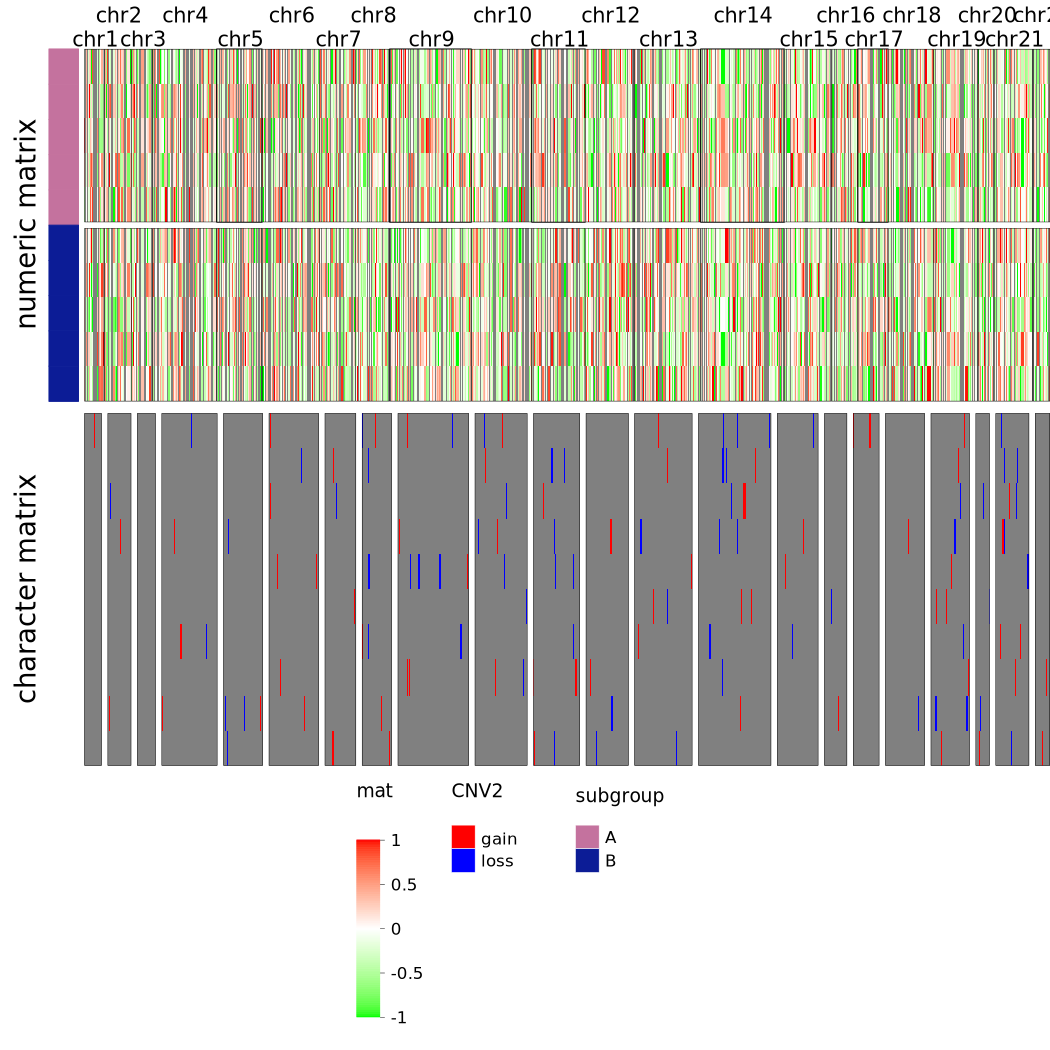

HeatmapList(['mat', 'CNV2'], direction='vertical')

In [7]:
# Horizontal layout using %v% (R's %v% operator)
chr_titles = [
    ("\n" + c if i % 2 == 0 else c + "\n")
    for i, c in enumerate(chr_level)
]

ht_horiz = Heatmap(num_mat.values.T, name="mat", col=col_fun,
    column_split=chr_factor, cluster_columns=False,
    show_row_dend=False,
    row_split=subgroup_arr, cluster_row_slices=False,
    row_title="numeric matrix",
    left_annotation=rowAnnotation(subgroup=subgroup_arr, show_annotation_name=False),
    column_title_gp=gp.Gpar(fontsize=10),
    border=True,
    column_gap=gp.Unit(0, "points"),
    column_title=chr_titles,
    show_column_names=False,
) % \
Heatmap(char_mat.values.T, name="CNV2",
    col={"gain": "red", "loss": "blue"},
    border=True, row_title="character matrix",
    show_column_names=False,
)
ht_horiz.draw(heatmap_legend_side="bottom")

## Summary

This tutorial demonstrated genome-level heatmap visualization:

- Pre-processed genomic data loaded via `load_genome_level_data()`
- Chromosome ordering via `pd.Categorical` with ordered levels
- `row_split` for splitting rows by chromosome (preserves category order)
- `column_split` for splitting columns by sample subgroup
- `row_title_rot=0` for horizontal chromosome labels
- `row_gap=Unit(0, "points")` for compact chromosome display
- `anno_mark` for gene labels with connector lines
- `anno_points` with per-column `gp.col` and `pch` for multi-track scatter
- `anno_barplot` with conditional per-bar coloring
- Multi-track composition via `+` operator
- Vertical concatenation via `%` operator (R's `%v%`)
- `draw(merge_legends=True)` to consolidate legends